# Неделя 1: MDP, Dynamic Programming и Model-Free RL

Ноутбук сопровождает файлы `01_mdp_and_bellman.md`, `02_dynamic_programming.md`, `03_model_free_rl.md` и `04_practice_and_mlops.md`. Мы построим настраиваемый GridWorld, решим его через Value Iteration и Policy Iteration, затем обучим SARSA и Q-Learning.

In [1]:
from dataclasses import dataclass
from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np

@dataclass
class Config:
    rows: int = 5
    cols: int = 6
    start: Tuple[int, int] = (4, 0)
    goal: Tuple[int, int] = (0, 5)
    walls: Tuple[Tuple[int, int], ...] = ((1, 1), (1, 2), (2, 3), (3, 1))
    step_reward: float = -0.04
    goal_reward: float = 1.0
    wall_reward: float = -0.20
    slip_probability: float = 0.0
    gamma: float = 0.95
    alpha: float = 0.10
    episodes: int = 1500
    max_steps: int = 100
    seed: int = 42

config = Config()
ACTIONS = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
ACTION_SYMBOLS = {0: "^", 1: ">", 2: "v", 3: "<"}
print(config)

Config(rows=5, cols=6, start=(4, 0), goal=(0, 5), walls=((1, 1), (1, 2), (2, 3), (3, 1)), step_reward=-0.04, goal_reward=1.0, wall_reward=-0.2, slip_probability=0.0, gamma=0.95, alpha=0.1, episodes=1500, max_steps=100, seed=42)


In [2]:
class GridWorld:
    def __init__(self, config: Config):
        self.config = config
        self.states = [(r, c) for r in range(config.rows) for c in range(config.cols) if (r, c) not in config.walls]
        self.state_to_id = {state: i for i, state in enumerate(self.states)}
        self.n_states = len(self.states)
        self.n_actions = len(ACTIONS)
        self.rng = np.random.default_rng(config.seed)
        self.reset()

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.position = self.config.start
        self.steps = 0
        return self.state_to_id[self.position]

    def _next_position(self, position, action):
        r, c = position
        dr, dc = ACTIONS[action]
        candidate = (r + dr, c + dc)
        if not (0 <= candidate[0] < self.config.rows and 0 <= candidate[1] < self.config.cols):
            return position
        return position if candidate in self.config.walls else candidate

    def transition(self, state_id, action):
        actual_action = action
        if self.config.slip_probability and self.rng.random() < self.config.slip_probability:
            actual_action = int(self.rng.integers(self.n_actions))
        position = self.states[state_id]
        next_position = self._next_position(position, actual_action)
        next_state = self.state_to_id[next_position]
        done = next_position == self.config.goal
        if done:
            reward = self.config.goal_reward
        elif next_position == position and position != self.config.start:
            reward = self.config.wall_reward
        else:
            reward = self.config.step_reward
        return next_state, reward, done

    def step(self, action):
        next_state, reward, done = self.transition(self.state_to_id[self.position], action)
        self.position = self.states[next_state]
        self.steps += 1
        return next_state, reward, done or self.steps >= self.config.max_steps

    def model(self, state_id, action):
        outcomes = [(1.0, action)]
        if self.config.slip_probability:
            p = self.config.slip_probability / self.n_actions
            outcomes = [(1 - self.config.slip_probability, action)] + [(p, a) for a in range(self.n_actions)]
        result = []
        position = self.states[state_id]
        for probability, actual_action in outcomes:
            next_position = self._next_position(position, actual_action)
            next_state = self.state_to_id[next_position]
            done = next_position == self.config.goal
            if done:
                reward = self.config.goal_reward
            elif next_position == position and position != self.config.start:
                reward = self.config.wall_reward
            else:
                reward = self.config.step_reward
            result.append((probability, next_state, reward, done))
        return result

env = GridWorld(config)
print(f"states={env.n_states}, actions={env.n_actions}")

states=26, actions=4


## 1. MDP и Dynamic Programming

Модель среды позволяет вычислить ожидаемый return для каждой пары `(state, action)`. Поэтому Value Iteration применяет оптимальное уравнение Беллмана, а Policy Iteration чередует оценку текущей policy и её улучшение.

In [3]:
def expected_return(env, state, action, values):
    return sum(p * (reward + (0 if done else env.config.gamma * values[next_state])) for p, next_state, reward, done in env.model(state, action))

def value_iteration(env, theta=1e-8):
    values = np.zeros(env.n_states)
    for iteration in range(10_000):
        updated = values.copy()
        for state in range(env.n_states):
            if env.states[state] != env.config.goal:
                updated[state] = max(expected_return(env, state, action, values) for action in range(env.n_actions))
        delta = np.max(np.abs(updated - values))
        values = updated
        if delta < theta:
            break
    policy = np.array([
        0 if env.states[state] == env.config.goal else int(np.argmax([expected_return(env, state, a, values) for a in range(env.n_actions)]))
        for state in range(env.n_states)
    ])
    return values, policy, iteration + 1

def policy_iteration(env, theta=1e-8):
    policy = np.zeros(env.n_states, dtype=int)
    values = np.zeros(env.n_states)
    for outer in range(10_000):
        for _ in range(10_000):
            updated = values.copy()
            for state in range(env.n_states):
                if env.states[state] != env.config.goal:
                    updated[state] = expected_return(env, state, policy[state], values)
            if np.max(np.abs(updated - values)) < theta:
                values = updated
                break
            values = updated
        old_policy = policy.copy()
        for state in range(env.n_states):
            if env.states[state] != env.config.goal:
                policy[state] = int(np.argmax([expected_return(env, state, a, values) for a in range(env.n_actions)]))
        if np.array_equal(old_policy, policy):
            break
    return values, policy, outer + 1

vi_values, vi_policy, vi_rounds = value_iteration(env)
pi_values, pi_policy, pi_rounds = policy_iteration(env)
print(f"Value Iteration rounds: {vi_rounds}")
print(f"Policy Iteration rounds: {pi_rounds}")
print(f"Start values: VI={vi_values[env.state_to_id[config.start]]:.4f}, PI={pi_values[env.state_to_id[config.start]]:.4f}")

Value Iteration rounds: 10
Policy Iteration rounds: 5
Start values: VI=0.3942, PI=0.3942


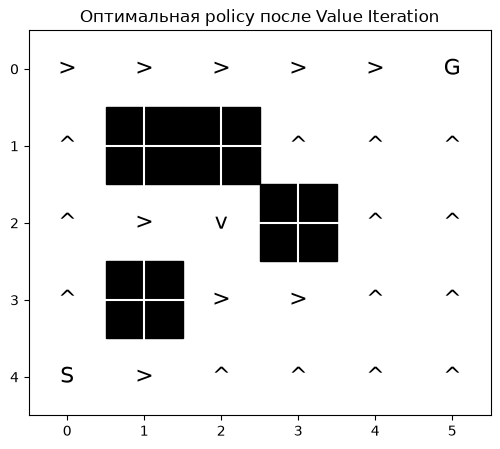

In [4]:
def draw_policy(env, policy, title):
    canvas = np.zeros((env.config.rows, env.config.cols))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(canvas, cmap="Greys", vmin=0, vmax=1)
    for r in range(env.config.rows):
        for c in range(env.config.cols):
            position = (r, c)
            if position in env.config.walls:
                ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1, color="black"))
            elif position == env.config.goal:
                ax.text(c, r, "G", ha="center", va="center", fontsize=16)
            elif position == env.config.start:
                ax.text(c, r, "S", ha="center", va="center", fontsize=16)
            else:
                ax.text(c, r, ACTION_SYMBOLS[int(policy[env.state_to_id[position]])], ha="center", va="center", fontsize=16)
    ax.set(title=title, xticks=range(env.config.cols), yticks=range(env.config.rows))
    ax.grid(color="white", linewidth=1.5)
    plt.show()

draw_policy(env, vi_policy, "Оптимальная policy после Value Iteration")

## 2. Model-Free RL: SARSA и Q-Learning

Теперь модель переходов не используется в обновлении. Агент получает опыт из `step`: `state, action, reward, next_state, done`. SARSA использует фактически выбранное следующее действие, а Q-Learning строит target через максимум по действиям.

In [5]:
def epsilon_greedy(q_values, state, epsilon, generator):
    if generator.random() < epsilon:
        return int(generator.integers(q_values.shape[1]))
    best = np.flatnonzero(q_values[state] == np.max(q_values[state]))
    return int(generator.choice(best))

def train_tabular(env, algorithm, episodes=None, seed=42):
    episodes = episodes or env.config.episodes
    generator = np.random.default_rng(seed)
    q_values = np.zeros((env.n_states, env.n_actions))
    returns, successes = [], []
    for episode in range(episodes):
        state = env.reset(seed=seed + episode)
        epsilon = max(0.05, 1.0 - episode / max(1, episodes * 0.8))
        action = epsilon_greedy(q_values, state, epsilon, generator)
        total_reward = 0.0
        for _ in range(env.config.max_steps):
            next_state, reward, done = env.step(action)
            total_reward += reward
            if algorithm == "sarsa":
                next_action = epsilon_greedy(q_values, next_state, epsilon, generator)
                target = reward if done else reward + env.config.gamma * q_values[next_state, next_action]
            elif algorithm == "q_learning":
                next_action = epsilon_greedy(q_values, next_state, epsilon, generator)
                target = reward if done else reward + env.config.gamma * np.max(q_values[next_state])
            else:
                raise ValueError("algorithm must be 'sarsa' or 'q_learning'")
            q_values[state, action] += env.config.alpha * (target - q_values[state, action])
            if done:
                break
            state, action = next_state, next_action
        returns.append(total_reward)
        successes.append(float(env.position == env.config.goal))
    return q_values, np.array(returns), np.array(successes)

sarsa_q, sarsa_returns, sarsa_successes = train_tabular(env, "sarsa", seed=7)
qlearn_q, qlearn_returns, qlearn_successes = train_tabular(env, "q_learning", seed=7)
print(f"SARSA final success rate: {sarsa_successes[-100:].mean():.2%}")
print(f"Q-Learning final success rate: {qlearn_successes[-100:].mean():.2%}")

SARSA final success rate: 100.00%
Q-Learning final success rate: 100.00%


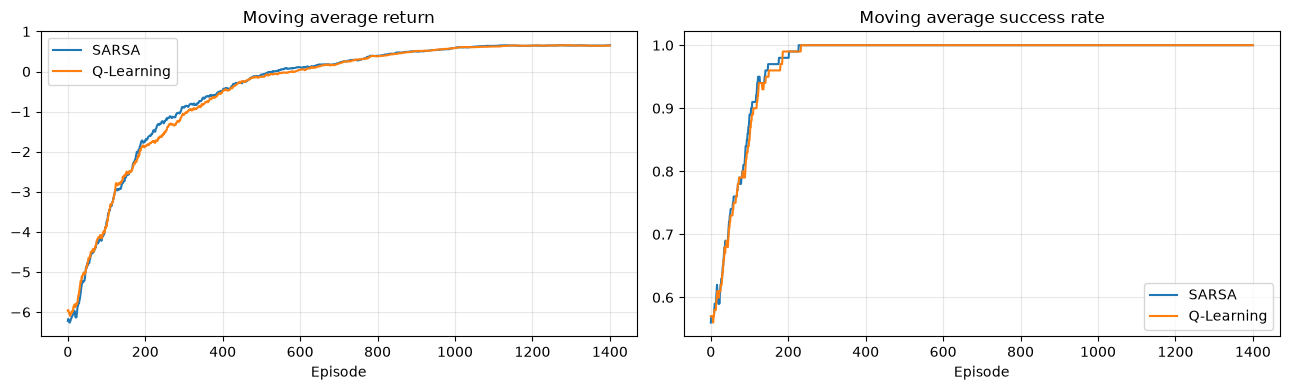

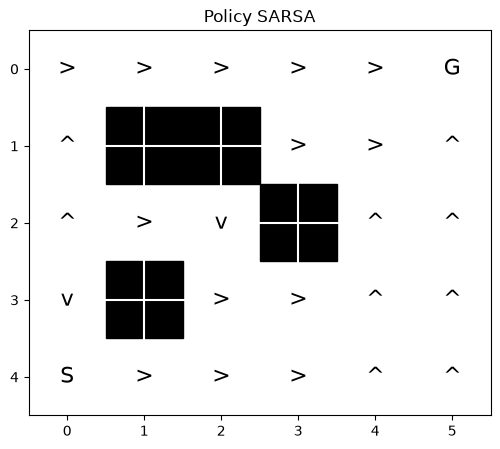

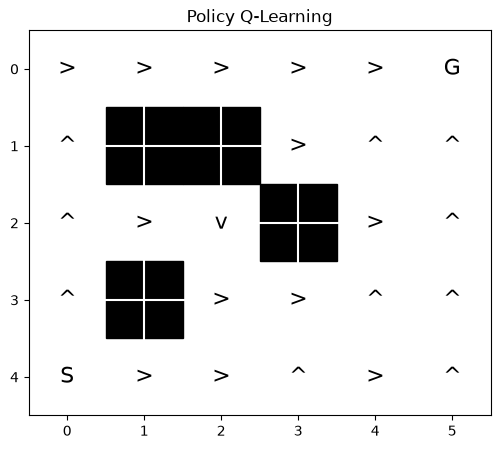

In [6]:
def moving_average(values, window=100):
    return np.convolve(values, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, returns, successes, color in [
    ("SARSA", sarsa_returns, sarsa_successes, "tab:blue"),
    ("Q-Learning", qlearn_returns, qlearn_successes, "tab:orange"),
]:
    axes[0].plot(moving_average(returns), label=label, color=color)
    axes[1].plot(moving_average(successes), label=label, color=color)
axes[0].set_title("Moving average return")
axes[1].set_title("Moving average success rate")
for axis in axes:
    axis.set_xlabel("Episode")
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

draw_policy(env, np.argmax(sarsa_q, axis=1), "Policy SARSA")
draw_policy(env, np.argmax(qlearn_q, axis=1), "Policy Q-Learning")

## 3. Самостоятельные эксперименты и MLOps

- [ ] Поставить `slip_probability=0.2` и сравнить устойчивость SARSA и Q-Learning.
- [ ] Изменить `step_reward` и проверить длину найденного маршрута.
- [ ] Повторить обучение на seeds `[1, 7, 21, 42, 100]` и вывести среднее и стандартное отклонение.
- [ ] Сохранять конфигурацию и Q-table как артефакты, а метрики return/success rate писать в CSV или MLflow.
- [ ] Вынести `GridWorld` и алгоритмы в отдельные модули и добавить smoke-test короткого запуска.

Ключевой вопрос: почему SARSA и Q-Learning могут прийти к разным маршрутам, хотя используют одну и ту же среду?